In [21]:
{"tags": ["hide_output"]}
%pip install pyunicorn > /dev/null
%pip install multiSyncPy > /dev/null
%pip install statsmodels > /dev/null

# clean and prepare data.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')


#clean and preprocess the data
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Step 1: Set datetime as the index
df = df.set_index('datetime')

# Step 2: Keep only the columns we need
df = df[['pm2.5', 'TEMP', 'PRES', 'Iws']]

# Step 3: Rename for convenience
df.columns = ['pm25', 'temp', 'pressure', 'wind']

df = df.fillna(method='ffill')

# Step 6: Resample hourly data to daily averages
df_daily = df.resample('D').mean()

df_daily = df_daily.bfill()

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


\
**Are Temperature, Wind, Air Pollution, and Air Pressure Intertwined?**

Group 1

In [22]:
import nbformat
from pathlib import Path

# notebook filename
notebook_path = "Module 9.ipynb"

# load notebook
nb = nbformat.read(notebook_path, as_version=4)

# collect markdown text
markdown_text = ""

for cell in nb.cells:
    if cell.cell_type == "markdown":
        markdown_text += cell.source + " "

# count words
word_count = len(markdown_text.split())

print(f"Markdown word count: {word_count}")

Markdown word count: 1955


# Introduction
This module examines how multivariate analyses work, focusing on the dynamics of temperature, wind, air polution and air pressure and how these factors are interrelated. To test this, we will use the dataset: Beijing PM2.5 Data (**Source:** Liang et al. (2015) — Assessing Beijing's PM2.5 pollution: Severity, weather impact, APEC and winter heating.).

To get an initial impression of what the data we are working with looks like, we will visualise the three variables in a plot. This will show the ranges and changes over time, and whether we are dealing with a chaotic system or whether patterns can already be identified. 

In [23]:
print(f"\nBasic statistics:")
df_daily.describe().round(2)


Basic statistics:


,pm25,temp,pressure,wind
count,1826.00,1826.00,1826.00,1826.00
mean,97.81,12.45,1016.45,23.89
std,76.96,11.56,10.07,41.36
min,2.96,-14.46,994.04,1.41
25%,41.65,1.54,1007.94,5.91
50%,78.56,13.90,1016.23,10.95
75%,131.04,23.17,1024.53,22.23
max,541.04,32.88,1043.46,463.19


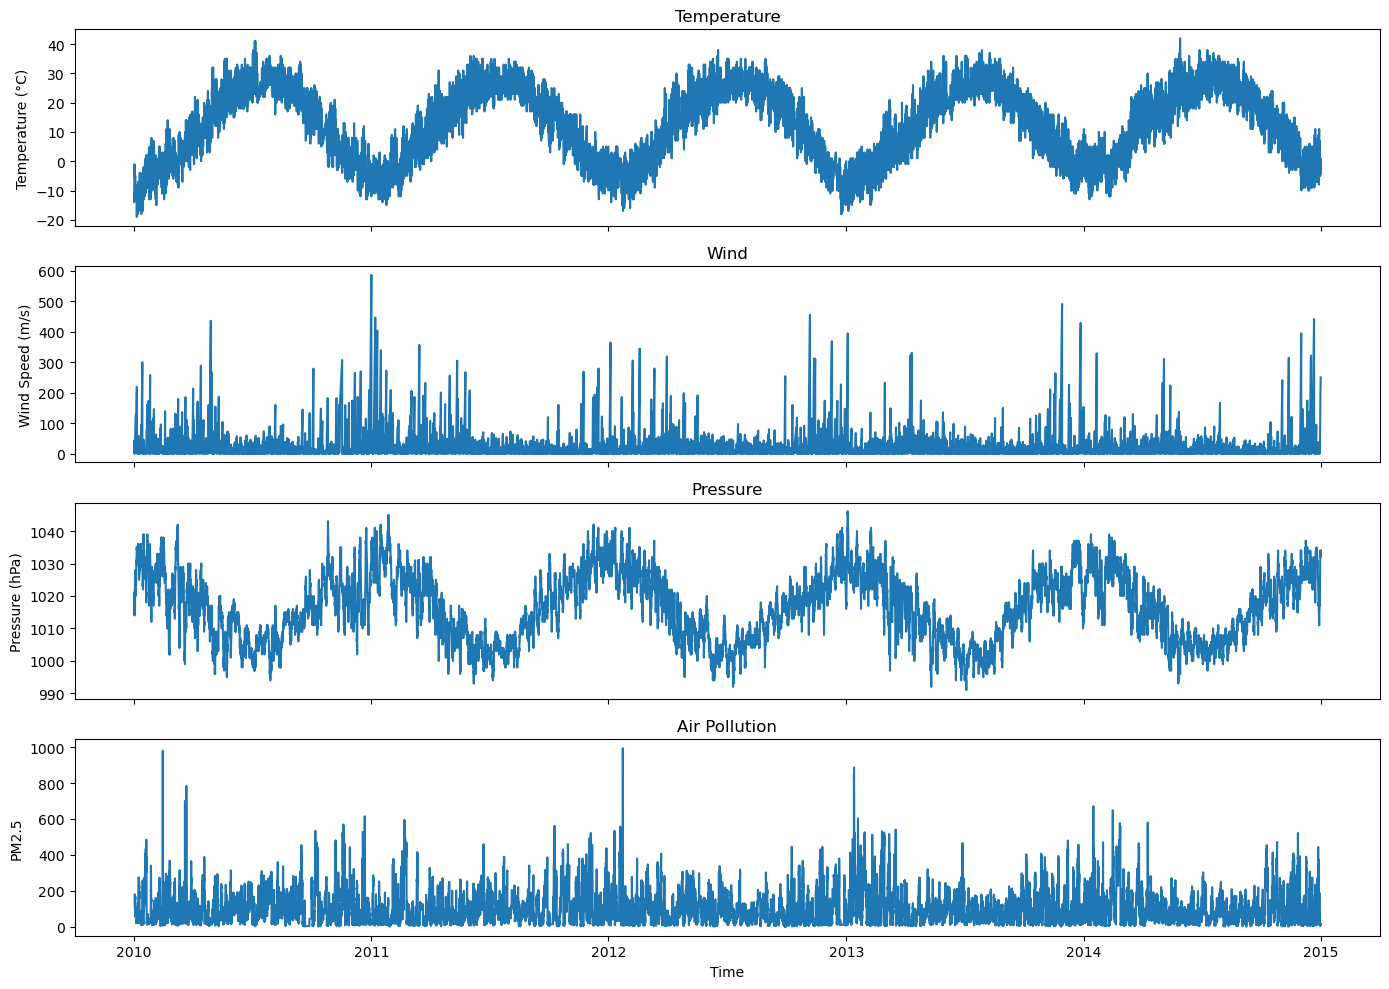

In [24]:
# plot
fig, axes = plt.subplots(4,1, figsize = (14,10), sharex = True)

# temperatuur
axes[0].plot(df.index, df["temp"])
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Temperature")

# wind
axes[1].plot(df.index, df["wind"])
axes[1].set_ylabel("Wind Speed (m/s)")
axes[1].set_title("Wind")

# luchtdruk
axes[2].plot(df.index, df["pressure"])
axes[2].set_ylabel("Pressure (hPa)")
axes[2].set_title("Pressure")

# PM2.5
axes[3].plot(df.index, df["pm25"])
axes[3].set_ylabel("PM2.5")
axes[3].set_title("Air Pollution")

plt.xlabel("Time")
plt.tight_layout()
plt.show()

The graph clearly shows that the temperature follows a sinusoidal pattern each year, moving in roughly the opposite direction to air pressure. Wind speeds are more difficult to correlate. What is striking is that in areas where the temperature is lowest, the wind speed is slightly higher than during warmer periods. Air pollution is also difficult to identify, but here too it can be seen that there is less PM2.5 present during warmer periods than during colder periods. 

For these data (temperature, wind speed, air pressure and PM2.5), a combination of correlation-based and time-dependent coordination methods appears to be the most suitable. As the variables are continuous meteorological time series, Pearson and Spearman correlations provide a logical starting point for investigating general relationships between variables (Pearson Product-Moment Correlation, z.d.; Spearman’s Rank-Order Correlation, z.d.). Pearson is suitable for linear relationships, whilst Spearman works better when relationships are non-linear or monotonic. Furthermore, weather systems are dynamic and time-dependent. Therefore, methods such as coherence or time-varying synchrony can provide additional information about shared rhythms or delays between variables. For example: changes in air pressure may precede changes in temperature; PM2.5 may respond to changes in wind speed; daily cycles may become apparent in multiple signals simultaneously.
Therefore, a combination of correlation analysis, time series analysis, and possibly coherence analysis appears to be the most suitable approach for characterising the coordination between these variables.

So we start with Pearson and Spearman.

In [25]:
#Pearson and spearman tests. 
variables = ['pm25', 'temp', 'pressure', 'wind']

pearson_corr = df[variables].corr(method="pearson")
print("Pearson \n", pearson_corr, " \n")

spearman_corr = df[variables].corr(method="spearman")
print("Spearman \n", spearman_corr)

Pearson 
               pm25      temp  pressure      wind
pm25      1.000000 -0.077869 -0.057439 -0.243067
temp     -0.077869  1.000000 -0.826690 -0.154623
pressure -0.057439 -0.826690  1.000000  0.185355
wind     -0.243067 -0.154623  0.185355  1.000000  

Spearman 
               pm25      temp  pressure      wind
pm25      1.000000  0.028111 -0.155680 -0.347202
temp      0.028111  1.000000 -0.832572  0.014604
pressure -0.155680 -0.832572  1.000000  0.054338
wind     -0.347202  0.014604  0.054338  1.000000


The Pearson correlation test indicates whether there is a linear relationship, whilst Spearman’s correlation test indicates whether there is any relationship at all. The Pearson correlation test shows that temperature and pressure have a strong negative correlation. This was also evident in the plot: as the temperature rose, the air pressure fell. Wind and air pollution also appeared to have a slight correlation, but not a linear one, so we look at the Spearman. Here too, a correlation is confirmed, with a Spearman coefficient of 0.35. This does not indicate a strong correlation, but rather a weak to moderate one, so it does suggest more than just random variation. The rest of the Pearson and Spearman values are too low to be called a correlation. 

Based on this test, we can conclude that there is a correlation between temperature and air pressure; however, we will conduct further tests to investigate other correlations. In complex systems such as weather and environmental data, different methods can reveal different aspects of the system. Therefore, using multiple analyses is often more reliable than relying on a single measure.

We will therefore now focus on the next step: time-dependent analyses. 

# Time-dependent analyses
As we are aware of the strong link between temperature and air pressure, we will explore the relationships that we do not yet fully understand. This leaves us with three relationships that are of particular interest: temperature and wind, temperature and air pollution, and wind and air pollution. As temperature and air pressure are so closely linked, it is less valuable to examine these relationships in relation to air pressure, so we will skip them. We will start with temperature and wind. 

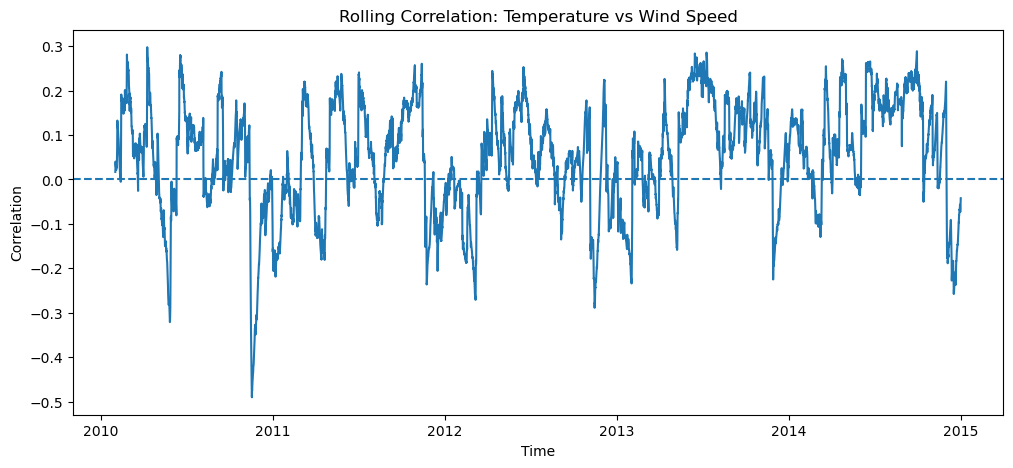

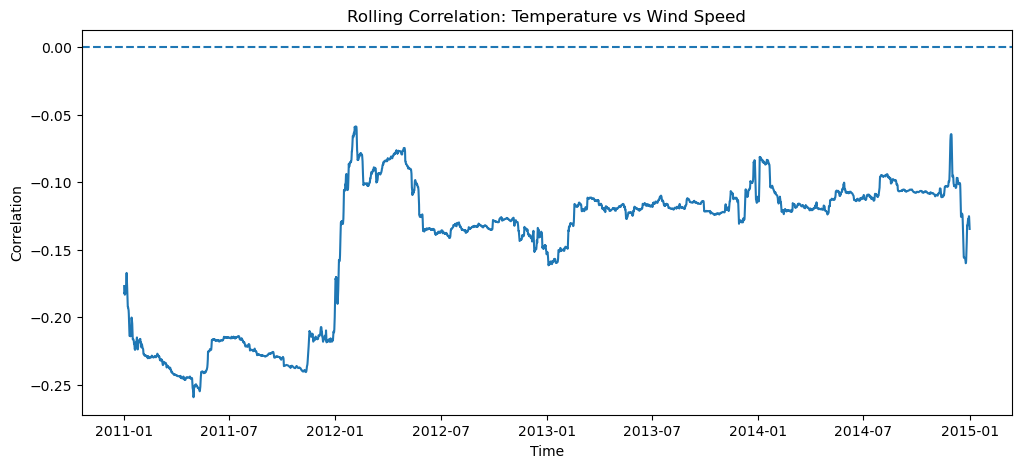

In [26]:
# rolling correlatie
rolling_corr = (
    df["temp"]
    .rolling(window=720)
    .corr(df["wind"])
)

# plot
plt.figure(figsize=(12,5))
plt.plot(df.index, rolling_corr)

plt.title("Rolling Correlation: Temperature vs Wind Speed")
plt.ylabel("Correlation")
plt.xlabel("Time")

plt.axhline(0, linestyle="--")

plt.show()

# rolling correlatie
rolling_corr = (
    df["temp"]
    .rolling(window=8760)
    .corr(df["wind"])
)

# plot
plt.figure(figsize=(12,5))
plt.plot(df.index, rolling_corr)

plt.title("Rolling Correlation: Temperature vs Wind Speed")
plt.ylabel("Correlation")
plt.xlabel("Time")

plt.axhline(0, linestyle="--")

plt.show()

To begin this analysis, we first look at the rolling correlation (Bogwasi & Bogwasi, 2026), with the first chart showing the weekly rolling correlation and the second chart showing the annual one. In the weekly chart, the correlation does not make much sense; nor does it appear to follow a logical pattern over the course of the year. The only thing that stands out is that, over the last 18 months, the correlations have been predominantly positive. The annual rolling correlation, however, paints a different picture. But with the exception of the first year, the correlation remains very constant. The next is Temprature and air pollution. 

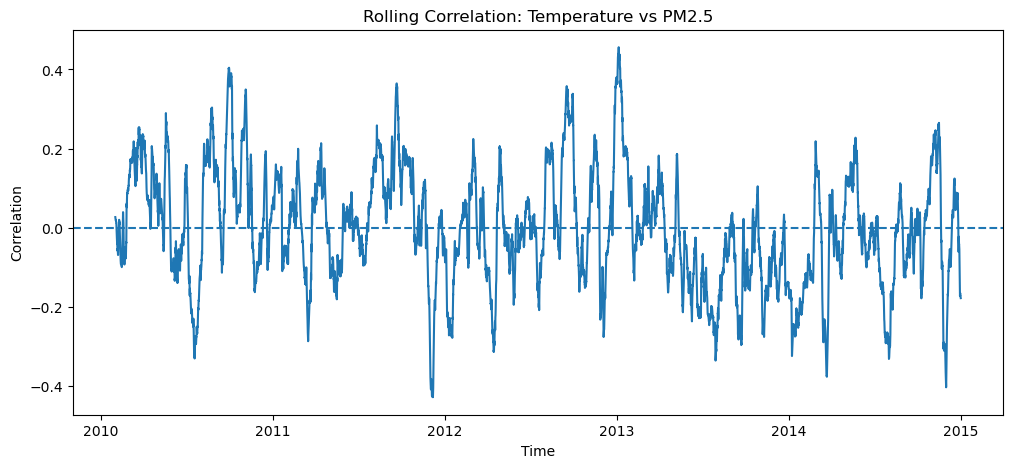

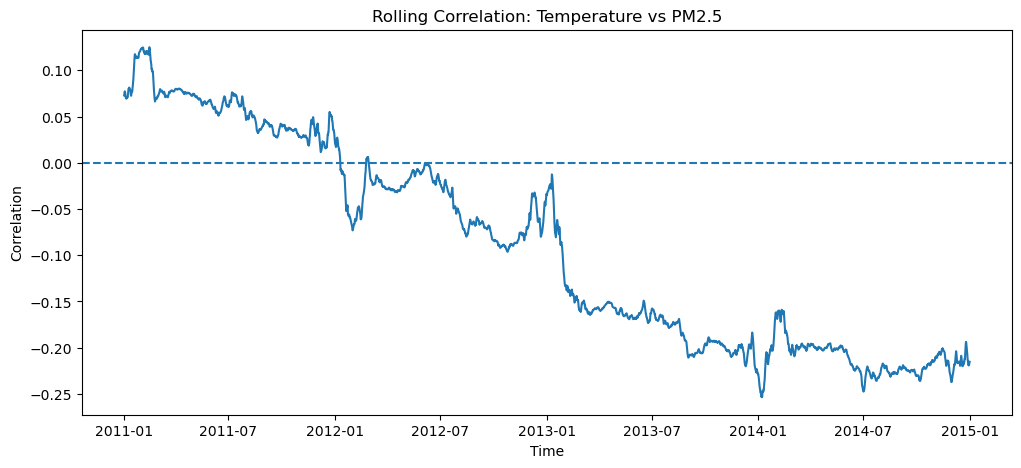

In [27]:
# rolling correlatie
rolling_corr = (
    df["temp"]
    .rolling(window=720)
    .corr(df["pm25"])
)

# plot
plt.figure(figsize=(12,5))
plt.plot(df.index, rolling_corr)

plt.title("Rolling Correlation: Temperature vs PM2.5")
plt.ylabel("Correlation")
plt.xlabel("Time")

plt.axhline(0, linestyle="--")

plt.show()

# rolling correlatie
rolling_corr = (
    df["temp"]
    .rolling(window=8760)
    .corr(df["pm25"])
)

# plot
plt.figure(figsize=(12,5))
plt.plot(df.index, rolling_corr)

plt.title("Rolling Correlation: Temperature vs PM2.5")
plt.ylabel("Correlation")
plt.xlabel("Time")

plt.axhline(0, linestyle="--")

plt.show()

This correlation also shows that there is no clear weekly pattern. The only thing that stands out is that from mid-2013 to early 2014 there was a period of low correlation, but this is not a convincing pattern. The annual rolling correlation does, however, show something interesting: it declines from a positive correlation to a negative correlation in a fairly linear line. This may indicate a change in the dynamics. The last factor we are looking at is wind speeds and air pollution. 

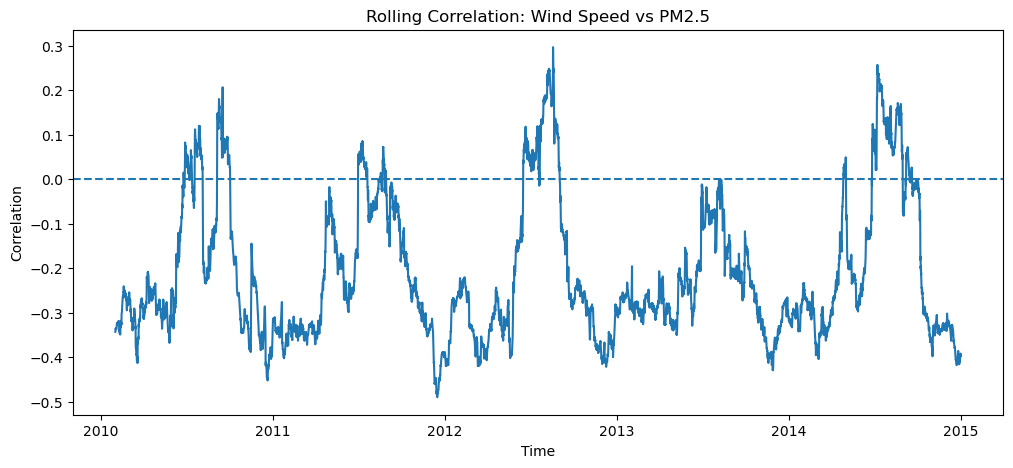

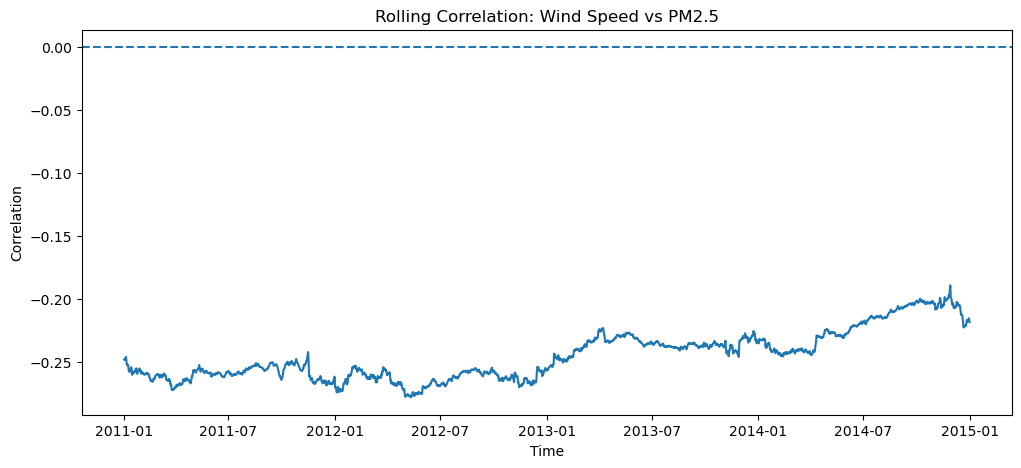

In [28]:
# rolling correlatie
rolling_corr = (
    df["wind"]
    .rolling(window=720)
    .corr(df["pm25"])
)

# plot
plt.figure(figsize=(12,5))
plt.plot(df.index, rolling_corr)

plt.title("Rolling Correlation: Wind Speed vs PM2.5")
plt.ylabel("Correlation")
plt.xlabel("Time")

plt.axhline(0, linestyle="--")

plt.show()

# rolling correlatie
rolling_corr = (
    df["wind"]
    .rolling(window=8760)
    .corr(df["pm25"])
)

# plot
plt.figure(figsize=(12,5))
plt.plot(df.index, rolling_corr)

plt.title("Rolling Correlation: Wind Speed vs PM2.5")
plt.ylabel("Correlation")
plt.xlabel("Time")

plt.axhline(0, linestyle="--")

plt.show()

The latter does reveal a pattern in the weekly rolling correlation. A clear peak consistently appears at 0.5–0.75 years, shifting from a deep negative correlation to a low positive correlation. This does indeed seem to indicate a correlation. The annual correlation shows that it remains fairly constant over time. 
Finally, within the time-dependent analysis, we look at the VAR (Vector Autoregression) (Lee, z.d.). 

In [29]:
from statsmodels.tsa.api import VAR

model_data = df[
    ["temp", "pressure", "wind", "pm25"]
]

model_data = model_data.dropna()

model = VAR(model_data)

results = model.fit(maxlags=5)

summary_df = pd.DataFrame({
    "coef": results.params.stack(),
    "pvalue": round(results.pvalues.stack(),3)
})

significant = summary_df[summary_df["pvalue"] < 0.05]

pd.set_option('display.max_rows', None)

print(significant)

                           coef  pvalue
const       temp      32.827613   0.000
            pressure   7.088583   0.000
L1.temp     temp       1.201336   0.000
            pressure  -0.055403   0.000
            wind       0.332719   0.000
            pm25      -0.716266   0.000
L1.pressure pressure   1.085555   0.000
            wind       0.647921   0.000
            pm25      -1.100092   0.000
L1.wind     temp      -0.002764   0.000
            pressure   0.001586   0.000
            wind       0.967398   0.000
            pm25      -0.027393   0.000
L1.pm25     pressure  -0.000821   0.000
            wind      -0.013947   0.000
            pm25       1.156912   0.000
L2.temp     wind      -0.271793   0.002
L2.pressure temp       0.106588   0.000
            pressure   0.116059   0.000
            wind      -0.585998   0.001
L2.pm25     pm25      -0.229442   0.000
L3.temp     temp      -0.106229   0.000
            pressure   0.007285   0.034
            pm25       0.500584   0.000


The VAR results show strong predictive dynamics within the variable itself, particularly at the first lag (1 hour ago). In addition, there are significant, albeit smaller, cross-variable effects, with air pressure playing a central role in the system by influencing temperature, wind and PM2.5. Air pollution exhibits strong persistence and responds to weather variables, indicating a dynamically coupled system of meteorological and environmental factors. To investigate this further, we will also examine the coherence and mdRQA. 

# Complexe dynamica
We’ll start with the coherence (Bertea, 2005), which assesses whether two time series move in tandem. Based on the previous analysis, this is what we expect for temperature and air pressure, but not really for the other factors. This is a measure that ranges from 0, which indicates no correlation, to 1, which indicates perfect synchronisation at that frequency. We’ll start with temperature and air pressure. 

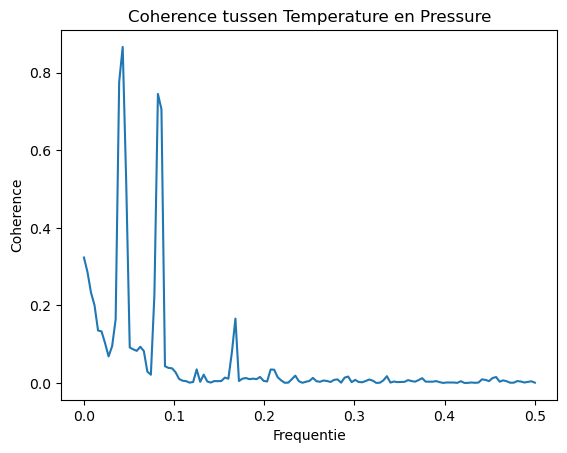

In [30]:
from scipy.signal import coherence

temps = df["temp"].to_numpy()
pressure = df["pressure"].to_numpy()

f, Cxy = coherence(temps, pressure, fs=1)

plt.plot(f, Cxy)
plt.xlabel("Frequentie")
plt.ylabel("Coherence")
plt.title("Coherence tussen Temperature en Pressure")
plt.show()

The coherence analysis reveals a strong correlation between temperature and pressure at low frequencies, suggesting shared long-term dynamics (such as seasonal or climatic patterns). At higher frequencies, the coherence is virtually zero, meaning that short-term fluctuations are not synchronised between the two variables. Next up is temperature and wind speeds. 

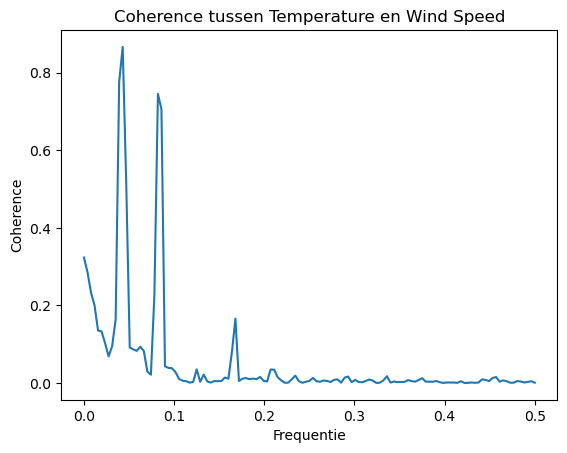

In [31]:
f, Cxy = coherence(df["temp"].values, df["pressure"].values, fs=1)

plt.plot(f, Cxy)
plt.xlabel("Frequentie")
plt.ylabel("Coherence")
plt.title("Coherence tussen Temperature en Wind Speed")
plt.show()

The coherence analysis shows weak correlation between temperature and wind at low frequencies, suggesting shared long-term dynamics (such as seasonal or climatic patterns). At higher frequencies, the coherence is virtually zero, meaning that short-term fluctuations are not synchronised between the two variables. Next is temperature and air pollution. 

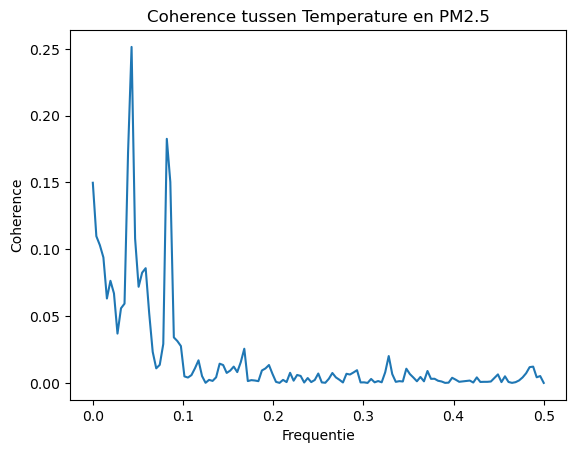

In [32]:
f, Cxy = coherence(model_data["temp"].to_numpy(), model_data["pm25"].to_numpy(), fs=1)
plt.plot(f, Cxy)
plt.xlabel("Frequentie")
plt.ylabel("Coherence")
plt.title("Coherence tussen Temperature en PM2.5")
plt.show()

The coherence analysis shows weak correlation between temperature and air pollution at low frequencies, suggesting shared long-term dynamics (such as seasonal or climatic patterns). At higher frequencies, the coherence is virtually zero, meaning that short-term fluctuations are not synchronised between the two variables. Next is temperature and air pollution.

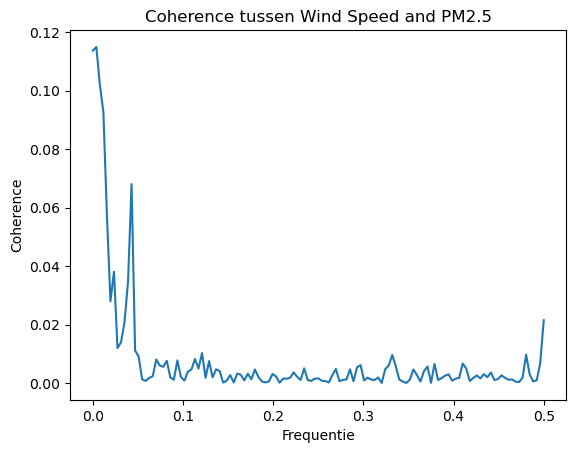

In [33]:
f, Cxy = coherence(model_data["wind"].to_numpy(), model_data["pm25"].to_numpy(), fs=1)

plt.plot(f, Cxy)
plt.xlabel("Frequentie")
plt.ylabel("Coherence")
plt.title("Coherence tussen Wind Speed and PM2.5")
plt.show()

The coherence analysis shows very weak correlation between wind speed and air pollution. So there is no real correlation between these two. At last the mdRQA. 

## Multivariate coordination

In [34]:
import multiSyncPy.synchrony_metrics as sm
from sklearn.preprocessing import StandardScaler

features = ['pm25', 'temp', 'pressure', 'wind']

data_subset = df_daily[features].dropna().values.T 

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_subset.T).T

# 'radius' is the threshold. 1.0 is a good starting point for scaled data.
rec_matrix = sm.recurrence_matrix(data_scaled, radius=1.0)

# 3. Calculate the RQA Metrics (including Determinism!)
# returns (Recurrence Rate, Determinism, Mean Diagonal, Max Diagonal)
rr, det, mean_diag, max_diag = sm.rqa_metrics(rec_matrix)

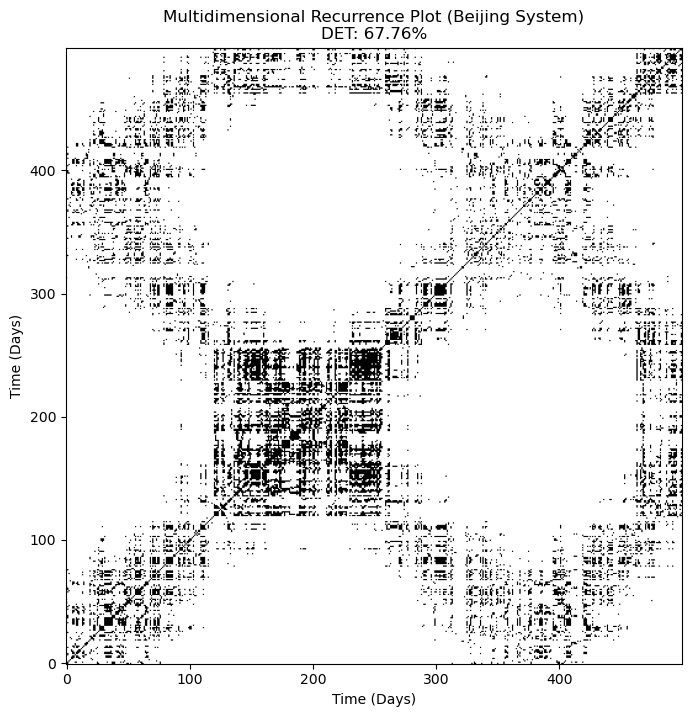

Multivariate Recurrence Rate: 0.1186
Multivariate Determinism (%DET): 0.6776


In [35]:
# Visualizing the Recurrence Matrix 
plt.figure(figsize=(8, 8))
plt.imshow(rec_matrix[:500, :500], cmap='binary', origin='lower')
plt.title(f"Multidimensional Recurrence Plot (Beijing System)\nDET: {det:.2%}")
plt.xlabel("Time (Days)")
plt.ylabel("Time (Days)")
plt.show()

print(f"Multivariate Recurrence Rate: {rr:.4f}")
print(f"Multivariate Determinism (%DET): {det:.4f}")

Based on the Multivariate Recurrence Rate (11.86%) and DET (67.76%), the analysis shows that a system that is moderately repetitive but highly structured and predictable. In the context of the Beijing dataset, the coordination between PM2,5 levels, temperature, air pressure,and wind speed in Beijing is defined as a non-linear deterministic System. Unlike the linear measures that assume a simple proportional relationship between the different variables, mdRQA is specifically designed to 'capture the degree to which a system's follows a trajectory in phase space' (Hudson, Wiltshire & Atzmueller,2023), proving that variables are appearing in an ordered sequence overtime. This high level of determinism suggests that pollution events in Beijing are part of coupled multivariate process where weather, and air quality variables constrain each other's future states. 

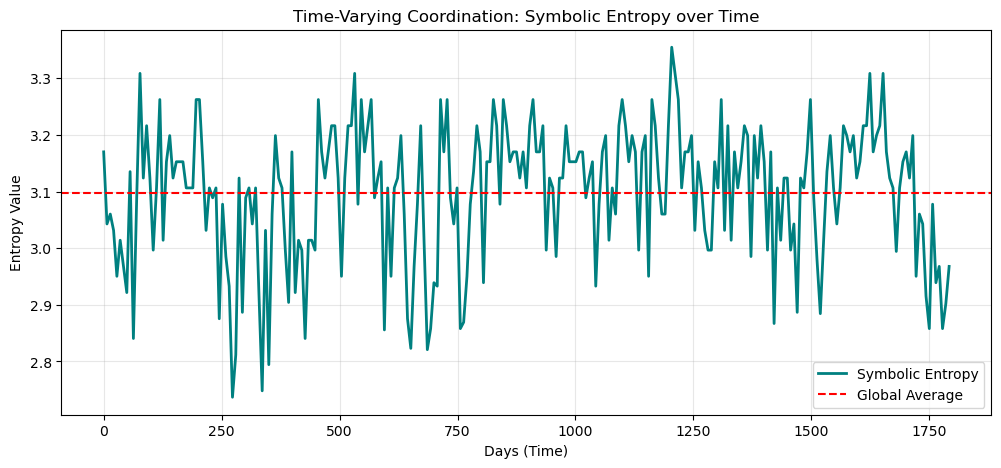

Multivariate Symbolic Entropy: 3.8134


In [36]:
# Calculate Symbolic Entropy
entropy_value = sm.symbolic_entropy(data_scaled)

# 1. Define window parameters
window_size = 30  # 30 days
step_size = 7     # Move by 1 week
n_timepoints = data_scaled.shape[1]

# 2. Manual Sliding Window Loop
windowed_entropy = []
window_indices = []

for start in range(0, n_timepoints - window_size, step_size):
    end = start + window_size
    # Slice the data for this window: (all variables, specific time range)
    window_data = data_scaled[:, start:end]
    
    # Calculate entropy for this specific window
    e = sm.symbolic_entropy(window_data)
    windowed_entropy.append(e)
    window_indices.append(start)

# 3. Plot the results
plt.figure(figsize=(12, 5))
plt.plot(window_indices, windowed_entropy, color='teal', linewidth=2, label='Symbolic Entropy')
plt.axhline(y=np.mean(windowed_entropy), color='red', linestyle='--', label='Global Average')
plt.title('Time-Varying Coordination: Symbolic Entropy over Time')
plt.xlabel('Days (Time)')
plt.ylabel('Entropy Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Multivariate Symbolic Entropy: {entropy_value:.4f}")

This analysis uses an information-theoric framework to measuire the regularity of shared patterns over time. The persistent fluctuations around the global average (3.1) shows the system non - stationarity. There is a sharp decreases in entropy that signifies transient periods of high coordination where the atmospheric variables (PM2.5, wind, pressure, temperature) enter highly ordered, deterministic regimes.

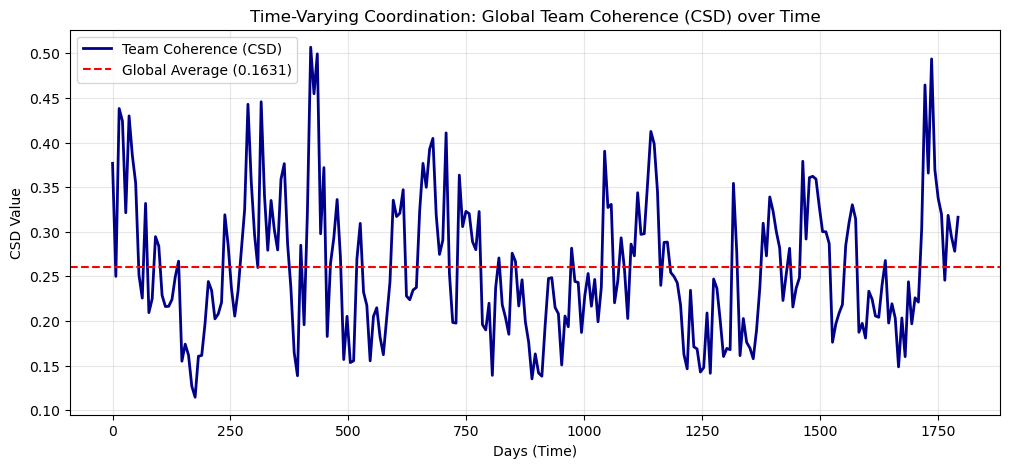

Global Team Coherence (Sum-Normalized CSD): 0.1631


In [37]:
# Calculate Sum-Normalized CSD (Global Team Coherence)
csd_value = sm.coherence_team(data_scaled)

# 1. Define window parameters (keeping them consistent with your entropy plot)
window_size = 30 
step_size = 7     
n_timepoints = data_scaled.shape[1]

# 2. Manual Sliding Window Loop for CSD
windowed_csd = []
window_indices = []

for start in range(0, n_timepoints - window_size, step_size):
    end = start + window_size
    window_data = data_scaled[:, start:end]
    
    # Calculate Team Coherence (Sum-Normalized CSD) for this window
    c = sm.coherence_team(window_data)
    windowed_csd.append(c)
    window_indices.append(start)

# 3. Plot the results
plt.figure(figsize=(12, 5))
plt.plot(window_indices, windowed_csd, color='darkblue', linewidth=2, label='Team Coherence (CSD)')
plt.axhline(y=np.mean(windowed_csd), color='red', linestyle='--', label='Global Average (0.1631)')
plt.title('Time-Varying Coordination: Global Team Coherence (CSD) over Time')
plt.xlabel('Days (Time)')
plt.ylabel('CSD Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Global Team Coherence (Sum-Normalized CSD): {csd_value:.4f}")

This frequency based analysis shows the non-stationary nature of the system rhythmic coordination. While the global average (red dash line) shows a linear line, the presence of the transient peaks (exceeding 0.45) shows brief periods of high frequency synchronization between PM2,5 and meteorological factors, likely corresponding to atmospheric regimes 

The conclusion of the mdRQA is that dynamically, the system shows a high Multivariate Determinism (%DET) of 67.76%, suggesting that the interaction between PM2.5 and weather variables follows structured, rule-governed trajectories (Wallot & Leonardi, 2018). But on the ther hand, the Frequency based analysis shows a low global team coherence of 0.1631, showing that this coordination is non linear and lacks simple rhythmic syncronization. 

The information-Theoretic framework, represented by the Symbolic Entropy (Global Average: 3.1), fluctuates significantly over the periof of 1,800 days. According to Hudson, Wiltshire, and Atzmueller (2023), these "peaks and valleys" indicate that the system's informational complexity is non-stationary; periods of lower entropy represent moments where the environment "locks" into highly ordered, predictable patterns of coordination. Based on this result, the %DET (67.76%) shown to be a useful baseline, and it masks the bursty nature of the systems. By triangulating these three frameworks, we can conclude that the Beijing environmental system is deeply coupled, non-linear unit shifts between different regimes of coordination overtime. 

# Conclusion
The results indicate that no single measure is sufficient to fully characterize coordination in this system. Instead, different analytical approaches capture distinct aspects of the underlying dynamics, including linear associations, temporal predictability, oscillatory structure, and informational complexity.

Multivariate recurrence quantification analysis (mdRQA) provides a particularly informative perspective on the temporal and multilevel structure of the system, revealing dynamic patterns that are not captured by static or purely frequency-based measures. However, this does not imply that mdRQA is superior; rather, it complements other methods by highlighting different properties of the data. Correlation- and coherence-based measures show partial overlap, particularly in capturing shared frequency structure, but they are not redundant, as each metric reflects different assumptions about the nature of coordination. In general, the results suggest that coordination is a multifaceted construct that cannot be reduced to a single statistical summary. Additional measures such as transfer entropy, Kuramoto order parameters, or cluster-phase synchronization could further extend the analysis by capturing nonlinear and directional interactions. However, the choice of method should always be guided by the specific research question rather than methodological accumulation.

Finally, the results demonstrate that time-averaged measures can obscure important temporal variability in the system. While averages provide useful summaries of overall tendencies, time-resolved metrics are essential for capturing transient coordination patterns and non-stationary dynamics. Overall, a multi-method approach is necessary not because more analysis is inherently better, but because different methods reveal complementary aspects of the same complex system.

# Resources
Bertea, S. (2005). The Arguments from Coherence: Analysis and Evaluation. http://ssrn.com/abstract=2112924

Bogwasi, T., & Bogwasi, T. (2026, 29 april). Rolling Correlation | Brimco. Brimco. https://www.brimco.io/terms/rolling-correlation/

Hudson, D., Wiltshire, T. J., & Atzmueller, M. (2023). multiSyncPy: A Python package for assessing multivariate coordination dynamics. Behavior Research Methods, 55(2), 932-962. https://link.springer.com/article/10.3758/s13428-022-01855-y

Lee, S. (z.d.). Complete Guide to Vector Autoregression: Methods for Forecasting. https://www.numberanalytics.com/blog/complete-guide-vector-autoregression

Pearson Product-Moment Correlation - When you should run this test, the range of values the coefficient can take and how to measure strength of association. (z.d.). https://statistics.laerd.com/statistical-guides/pearson-correlation-coefficient-statistical-guide.php

Spearman’s Rank-Order Correlation - A guide to when to use it, what it does and what the assumptions are. (z.d.). https://statistics.laerd.com/statistical-guides/spearmans-rank-order-correlation-statistical-guide.php


In [38]:
!jupyter nbconvert "Module 9.ipynb" \
  --to pdf \
  --no-input

[NbConvertApp] Converting notebook Module 9.ipynb to pdf
[NbConvertApp] Support files will be in Module 9_files/
[NbConvertApp] Making directory ./Module 9_files
[NbConvertApp] Writing 41305 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1032467 bytes to Module 9.pdf
